In [1]:
import anndata as ad
import shutil
import sys
from pathlib import Path

import celltypist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas.core.indexes.base as pandas_indexes_base
import scanpy as sc
import seaborn as sns
from celltypist import models
from scipy.sparse import csr_matrix

# Configuring scanpy's settings for outfits and visualization
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [8]:
adata = ad.read_h5ad("../data_interim/dimensionality_reduction.h5ad")

In [9]:
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=1)

In [11]:
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5, flavor="igraph", n_iterations=1)

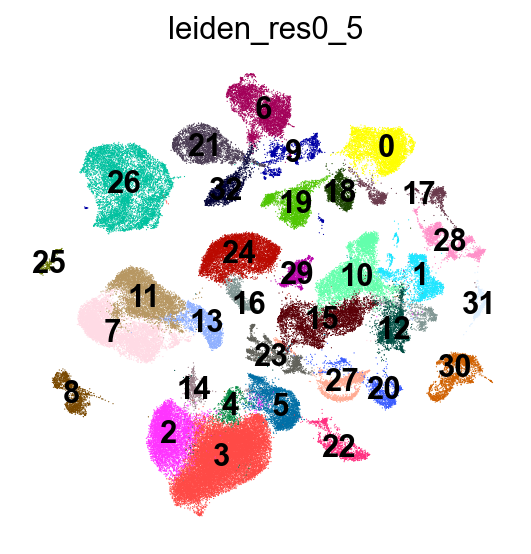

In [12]:
sc.pl.umap(adata,color="leiden_res0_5",legend_loc="on data")

In [13]:
sc.set_figure_params(figsize=(5, 5))

In [14]:
for i, ct in enumerate(adata.obs["cell_ontology_class"].unique(), 1):
    print(i, ct)

1 endothelial cell
2 B cell
3 mesenchymal stem cell of adipose
4 T cell
5 myeloid cell
6 epithelial cell
7 lymphocyte
8 erythroblast
9 mature NK T cell
10 plasma cell
11 proerythroblast
12 megakaryocyte-erythroid progenitor cell
13 NK cell
14 macrophage
15 immature NKT cell
16 macrophage dendritic cell progenitor
17 granulocyte
18 naive T cell
19 hematopoietic precursor cell
20 monocyte
21 promonocyte
22 granulocytopoietic cell
23 precursor B cell
24 late pro-B cell
25 naive B cell
26 erythroid progenitor
27 immature B cell
28 basophil
29 fibroblast of cardiac tissue
30 leukocyte
31 endocardial cell
32 smooth muscle cell
33 cardiomyocyte
34 endothelial cell of coronary artery
35 cardiac neuron
36 mast cell
37 erythrocyte
38 kidney proximal convoluted tubule epithelial cell
39 kidney loop of Henle thick ascending limb epithelial cell
40 kidney distal convoluted tubule epithelial cell
41 kidney loop of Henle ascending limb epithelial cell
42 kidney collecting duct principal cell
43 fenes

In [ ]:
celltype_dict = {
# endothelial
"endothelial cell": "endothelial",
"endothelial cell of coronary artery": "endothelial",
"endothelial cell of hepatic sinusoid": "endothelial",
"kidney capillary endothelial cell": "endothelial",
"vein endothelial cell": "endothelial",
"endothelial cell of lymphatic vessel": "endothelial",
"fenestrated cell": "endothelial",
"endocardial cell": "endothelial",
"kidney cortex artery cell": "endothelial",
# myeloid/macrophage
"myeloid cell": "myeloid/macrophage",
"macrophage": "myeloid/macrophage",
"lung macrophage": "myeloid/macrophage",
"alveolar macrophage": "myeloid/macrophage",
"Kupffer cell": "myeloid/macrophage",
"monocyte": "myeloid/macrophage",
"classical monocyte": "myeloid/macrophage",
"non-classical monocyte": "myeloid/macrophage",
"intermediate monocyte": "myeloid/macrophage",
"promonocyte": "myeloid/macrophage",
"myeloid leukocyte": "myeloid/macrophage",
"myeloid dendritic cell": "myeloid/macrophage",
"macrophage dendritic cell progenitor": "myeloid/macrophage",
"dendritic cell": "myeloid/macrophage",
"plasmacytoid dendritic cell": "myeloid/macrophage",
"granulocyte": "myeloid/macrophage",
"neutrophil": "myeloid/macrophage",
"basophil": "myeloid/macrophage",
"mast cell": "myeloid/macrophage",
"granulocytopoietic cell": "myeloid/macrophage",
# fibroblast/stromal
"fibroblast": "fibroblast/stromal",
"fibroblast of cardiac tissue": "fibroblast/stromal",
"fibroblast of lung": "fibroblast/stromal",
"pulmonary interstitial fibroblast": "fibroblast/stromal",
"mesenchymal stem cell of adipose": "fibroblast/stromal",
"hepatic stellate cell": "fibroblast/stromal",
"kidney mesangial cell": "fibroblast/stromal",
"adventitial cell": "fibroblast/stromal",
"pericyte cell": "fibroblast/stromal",
# immune lymphoid
"B cell": "lymphoid",
"T cell": "lymphoid",
"CD4-positive, alpha-beta T cell": "lymphoid",
"CD8-positive, alpha-beta T cell": "lymphoid",
"naive T cell": "lymphoid",
"regulatory T cell": "lymphoid",
"NK cell": "lymphoid",
"mature NK T cell": "lymphoid",
"immature NKT cell": "lymphoid",
"lymphocyte": "lymphoid",
"plasma cell": "lymphoid",
"naive B cell": "lymphoid",
"precursor B cell": "lymphoid",
"late pro-B cell": "lymphoid",
"immature B cell": "lymphoid",
# epithelial
"epithelial cell": "epithelial",
"kidney proximal convoluted tubule epithelial cell": "epithelial",
"kidney loop of Henle thick ascending limb epithelial cell": "epithelial",
"kidney distal convoluted tubule epithelial cell": "epithelial",
"kidney loop of Henle ascending limb epithelial cell": "epithelial",
"kidney collecting duct principal cell": "epithelial",
"epithelial cell of proximal tubule": "epithelial",
"brush cell": "epithelial",
"podocyte": "epithelial",
"kidney proximal straight tubule epithelial cell": "epithelial",
"kidney collecting duct epithelial cell": "epithelial",
"kidney cell": "epithelial",
"hepatocyte": "epithelial",
"duct epithelial cell": "epithelial",
"type II pneumocyte": "epithelial",
"ciliated columnar cell of tracheobronchial tree": "epithelial",
"club cell of bronchiole": "epithelial",
"lung neuroendocrine cell": "epithelial",
# muscle
"smooth muscle cell": "muscle",
"smooth muscle cell of the pulmonary artery": "muscle",
"bronchial smooth muscle cell": "muscle",
"cardiomyocyte": "muscle",
# hematopoietic/erythroid
"erythroblast": "hematopoietic/erythroid",
"proerythroblast": "hematopoietic/erythroid",
"erythroid progenitor": "hematopoietic/erythroid",
"megakaryocyte-erythroid progenitor cell": "hematopoietic/erythroid",
"erythrocyte": "hematopoietic/erythroid",
"hematopoietic precursor cell": "hematopoietic/erythroid",
# other
"cardiac neuron": "other",
"leukocyte": "other"
}

In [16]:
adata.obs["major_cell_type"] = (adata.obs["cell_ontology_class"].map(celltype_dict))

In [17]:
adata.write_h5ad("../data_interim/clustered.h5ad")

... storing 'major_cell_type' as categorical


In [2]:
adata = ad.read_h5ad("../data_interim/clustered.h5ad")

In [3]:
cell_count = (adata.obs.groupby(["mouse.id","tissue","major_cell_type"]).size().reset_index(name="cell_number"))

cell_count.head()

,mouse.id,tissue,major_cell_type,cell_number
0,1-M-62,Fat,endothelial,0
1,1-M-62,Fat,epithelial,0
2,1-M-62,Fat,fibroblast/stromal,0
3,1-M-62,Fat,hematopoietic/erythroid,0
4,1-M-62,Fat,lymphoid,0


In [4]:
cell_count.to_csv("../results/qc/final_cohort_matrix.csv",index=False)

In [5]:
coverage = (cell_count.pivot_table(index=["tissue","major_cell_type"],columns="mouse.id",values="cell_number",fill_value=0))

coverage.head()

mouse.id                        1-M-62  1-M-63  3-F-56  3-F-57  3-M-5/6  \
tissue major_cell_type                                                    
Fat    endothelial                 0.0     0.0     0.0     0.0      0.0   
       epithelial                  0.0     0.0     0.0     0.0      0.0   
       fibroblast/stromal          0.0     0.0     0.0     0.0      0.0   
       hematopoietic/erythroid     0.0     0.0     0.0     0.0      0.0   
       lymphoid                    0.0     0.0     0.0     0.0      0.0   

mouse.id                        3-M-7/8  3-M-8  3-M-8/9  3-M-9  18-F-50  ...  \
tissue major_cell_type                                                   ...   
Fat    endothelial                  0.0    0.0      0.0    0.0    275.0  ...   
       epithelial                   0.0    0.0      0.0    0.0     40.0  ...   
       fibroblast/stromal           0.0    0.0      0.0    0.0    308.0  ...   
       hematopoietic/erythroid      0.0    0.0      0.0    0.0      1.0  ...   
       lymphoid                     0.0    0.0      0.0    0.0    503.0  ...   

mouse.id                        21-F-54  21-F-55  24-M-58  24-M-59  24-M-60  \
tissue major_cell_type                                                        
Fat    endothelial                 68.0    112.0      0.0      0.0      0.0   
       epithelial                  27.0      8.0      0.0      0.0      0.0   
       fibroblast/stromal         111.0    122.0      0.0      0.0      0.0   
       hematopoietic/erythroid      0.0      2.0      0.0      0.0      0.0   
       lymphoid                    74.0     61.0      0.0      0.0      0.0   

mouse.id                        24-M-61  30-M-2  30-M-3  30-M-4  30-M-5  
tissue major_cell_type                                                   
Fat    endothelial                  0.0     0.0     0.0     0.0   589.0  
       epithelial                   0.0     0.0     0.0     0.0     2.0  
       fibroblast/stromal           0.0     0.0     0.0     0.0   648.0  
       hematopoietic/erythroid      0.0     0.0     0.0     0.0     2.0  
       lymphoid                     0.0     0.0     0.0     0.0   466.0  

[5 rows x 23 columns]

In [6]:
coverage_binary = coverage >= 30

coverage_summary = (coverage_binary.groupby(level=["tissue","major_cell_type"]).mean())

coverage_summary

mouse.id                                 1-M-62  1-M-63  3-F-56  3-F-57  \
tissue          major_cell_type                                           
Fat             endothelial                 0.0     0.0     0.0     0.0   
                epithelial                  0.0     0.0     0.0     0.0   
                fibroblast/stromal          0.0     0.0     0.0     0.0   
                hematopoietic/erythroid     0.0     0.0     0.0     0.0   
                lymphoid                    0.0     0.0     0.0     0.0   
                muscle                      0.0     0.0     0.0     0.0   
                myeloid/macrophage          0.0     0.0     0.0     0.0   
                other                       0.0     0.0     0.0     0.0   
Heart_and_Aorta endothelial                 0.0     1.0     1.0     0.0   
                epithelial                  0.0     0.0     0.0     0.0   
                fibroblast/stromal          0.0     1.0     1.0     0.0   
                hematopoietic/erythroid     0.0     0.0     0.0     0.0   
                lymphoid                    0.0     0.0     0.0     0.0   
                muscle                      0.0     1.0     1.0     0.0   
                myeloid/macrophage          0.0     0.0     0.0     0.0   
                other                       0.0     1.0     1.0     0.0   
Kidney          endothelial                 1.0     1.0     0.0     1.0   
                epithelial                  1.0     1.0     0.0     1.0   
                fibroblast/stromal          1.0     1.0     0.0     1.0   
                hematopoietic/erythroid     0.0     0.0     0.0     0.0   
                lymphoid                    0.0     0.0     0.0     0.0   
                muscle                      0.0     0.0     0.0     0.0   
                myeloid/macrophage          0.0     1.0     0.0     1.0   
                other                       0.0     0.0     0.0     0.0   
Liver           endothelial                 0.0     1.0     0.0     0.0   
                epithelial                  1.0     1.0     1.0     1.0   
                fibroblast/stromal          0.0     0.0     0.0     0.0   
                hematopoietic/erythroid     0.0     0.0     0.0     0.0   
                lymphoid                    0.0     1.0     0.0     0.0   
                muscle                      0.0     0.0     0.0     0.0   
                myeloid/macrophage          0.0     1.0     0.0     0.0   
                other                       0.0     0.0     0.0     0.0   
Lung            endothelial                 0.0     0.0     0.0     0.0   
                epithelial                  0.0     0.0     0.0     0.0   
                fibroblast/stromal          1.0     1.0     0.0     1.0   
                hematopoietic/erythroid     0.0     0.0     0.0     0.0   
                lymphoid                    1.0     1.0     1.0     1.0   
                muscle                      1.0     1.0     1.0     1.0   
                myeloid/macrophage          1.0     1.0     1.0     1.0   
                other                       0.0     0.0     0.0     0.0   
spleen/marrow   endothelial                 0.0     0.0     0.0     0.0   
                epithelial                  0.0     0.0     0.0     0.0   
                fibroblast/stromal          0.0     0.0     0.0     0.0   
                hematopoietic/erythroid     1.0     1.0     1.0     1.0   
                lymphoid                    1.0     1.0     1.0     1.0   
                muscle                      0.0     0.0     0.0     0.0   
                myeloid/macrophage          1.0     1.0     1.0     1.0   
                other                       0.0     0.0     0.0     0.0   

mouse.id                                 3-M-5/6  3-M-7/8  3-M-8  3-M-8/9  \
tissue          major_cell_type                                             
Fat             endothelial                  0.0      0.0    0.0      0.0   
                ep

In [ ]:
n_mouse = coverage_summary.shape[1]

coverage_table = (coverage_summary.sum(axis=1).reset_index())

coverage_table.columns = ["tissue","cell_type","mouse_pass_number"]

coverage_table["total_mouse"] = n_mouse

coverage_table["coverage"] = (coverage_table["mouse_pass_number"]/coverage_table["total_mouse"])

coverage_table = (coverage_table.sort_values("coverage",ascending=False))

coverage_table

,tissue,cell_type,mouse_pass_number,total_mouse,coverage
46,spleen/marrow,myeloid/macrophage,19.0,23,0.826087
43,spleen/marrow,hematopoietic/erythroid,18.0,23,0.782609
44,spleen/marrow,lymphoid,18.0,23,0.782609
38,Lung,myeloid/macrophage,15.0,23,0.652174
36,Lung,lymphoid,15.0,23,0.652174
17,Kidney,epithelial,14.0,23,0.608696
16,Kidney,endothelial,14.0,23,0.608696
22,Kidney,myeloid/macrophage,14.0,23,0.608696
37,Lung,muscle,13.0,23,0.565217
8,Heart_and_Aorta,endothelial,11.0,23,0.478261


In [8]:
coverage_table.to_csv("../results/tissue_celltype_coverage_statistics.csv",index=False)

In [9]:
target_cells = ["endothelial","fibroblast/stromal"]

target_table = coverage_table[coverage_table["cell_type"].isin(target_cells)]

target_table

,tissue,cell_type,mouse_pass_number,total_mouse,coverage
16,Kidney,endothelial,14.0,23,0.608696
8,Heart_and_Aorta,endothelial,11.0,23,0.478261
10,Heart_and_Aorta,fibroblast/stromal,10.0,23,0.434783
34,Lung,fibroblast/stromal,10.0,23,0.434783
0,Fat,endothelial,6.0,23,0.260870
32,Lung,endothelial,6.0,23,0.260870
2,Fat,fibroblast/stromal,6.0,23,0.260870
18,Kidney,fibroblast/stromal,5.0,23,0.217391
24,Liver,endothelial,2.0,23,0.086957
26,Liver,fibroblast/stromal,0.0,23,0.000000


In [ ]:
tissue_score = (target_table.groupby("tissue")["coverage"].mean().reset_index())

tissue_score.columns = ["tissue","mean_coverage"]

tissue_score = (tissue_score.sort_values("mean_coverage",ascending=False))

tissue_score

,tissue,mean_coverage
1,Heart_and_Aorta,0.456522
2,Kidney,0.413043
4,Lung,0.347826
0,Fat,0.260870
3,Liver,0.043478
5,spleen/marrow,0.000000


In [12]:
selected_tissues = tissue_score.iloc[:4]

backup_tissue = tissue_score.iloc[4:5]

print("正式分析组织:")
print(selected_tissues)

print("\n备用组织:")
print(backup_tissue)

正式分析组织:
            tissue  mean_coverage
1  Heart_and_Aorta       0.456522
2           Kidney       0.413043
4             Lung       0.347826
0              Fat       0.260870

备用组织:
  tissue  mean_coverage
3  Liver       0.043478


In [ ]:
selection = pd.DataFrame({
    "selection":["primary","primary","primary","primary","backup"],
    "tissue":pd.concat([selected_tissues["tissue"],backup_tissue["tissue"]]).values
})

selection

,selection,tissue
0,primary,Heart_and_Aorta
1,primary,Kidney
2,primary,Lung
3,primary,Fat
4,backup,Liver


In [17]:
selection.to_csv("../results/final_tissue_selection_endothelial_fibroblast.tsv",sep="\t",index=False)

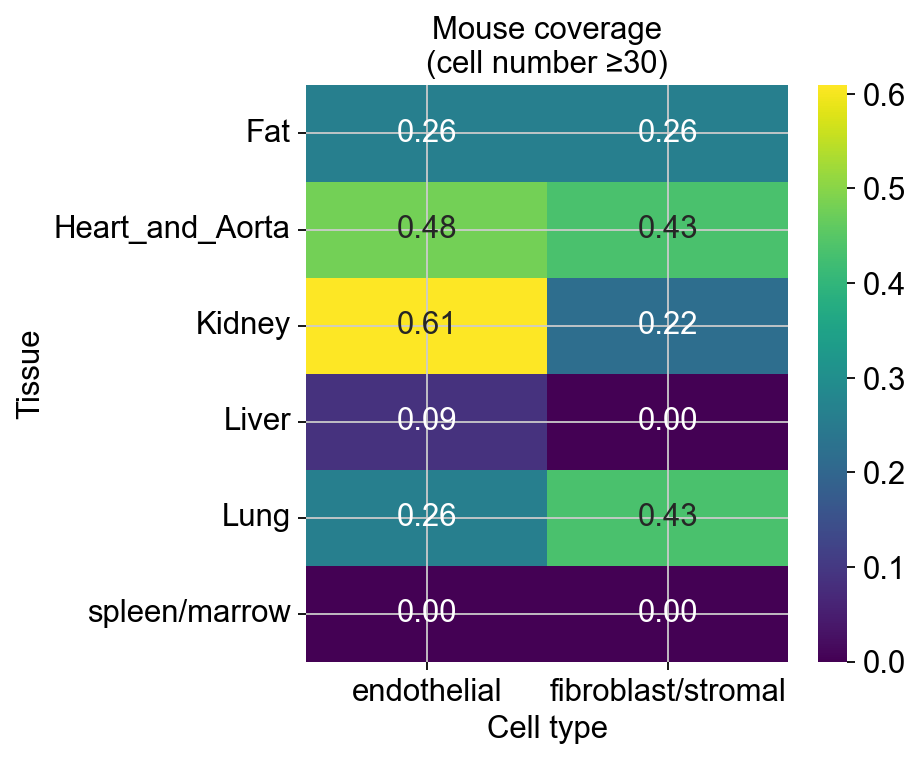

In [18]:
heatmap_data = (target_table.pivot(index="tissue",columns="cell_type",values="coverage"))

plt.figure(figsize=(6,5))

sns.heatmap(heatmap_data,annot=True,fmt=".2f",cmap="viridis")

plt.title("Mouse coverage\n(cell number ≥30)")

plt.ylabel("Tissue")
plt.xlabel("Cell type")

plt.tight_layout()

plt.savefig("../figures/tissue_celltype_coverage_heatmap.pdf",dpi=300)

plt.show()

In [21]:
target_tissues = ["Heart_and_Aorta","Kidney","Lung","Fat","Liver"]

target_celltypes = ["endothelial","fibroblast/stromal"]

adata_sub = adata[adata.obs["tissue"].isin(target_tissues)&adata.obs["major_cell_type"].isin(target_celltypes)].copy()

print(adata_sub)

AnnData object with n_obs × n_vars = 14257 × 3000
    obs: 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'n_counts', 'louvain', 'leiden', 'mouse_id_std', 'tissue_std', 'cell_type_original', 'age_months', 'age_group', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'leiden_res0_5', 'major_cell_type'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'hvg', 'leiden', 'leiden_res0_5', 'leiden_res0_5_colors', 'mouse.id_c

In [24]:
adata_sub.write_h5ad("../data_interim/tissuexcell.h5ad")